In [4]:
# models: clustering [kmeans, (with lda, svd), svm], neural networks w2v, logistic reg
# func eval_kmeans/svm (model, train,test) = acc, roc 
# def vectorize() = tfidf, counter, bow, embeddings
# pre processing -> vectorize/embeddings -> models 

In [17]:
# imports
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import cross_val_score, train_test_split,KFold
import os.path
import codecs
from preprocessing import preprocessing
from extraction_vocab_bow import exploration
from sklearn.cluster import KMeans

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
def load_movies(path2data):
    alltxts = [] # init vide
    labs = []
    cpt = 0
    for cl in os.listdir(path2data):
        for f in os.listdir(path2data+cl):
            txt = open(path2data+cl+'/'+f).read()
            alltxts.append(txt)
            labs.append(cpt)
        cpt+=1 
    return alltxts,labs

path = "./Dataset/movies1000/"
alltxts,alllabs = load_movies(path)

In [35]:
# preprocessing

def preprocess_texts(alltxts):
    return [preprocessing(text) for text in alltxts]

alltxts = preprocess_texts(alltxts[:20])

In [25]:
alltxts[0]

'bad . bad . \nbad . \nthat one word seems to pretty much sums up beyond the valley of the dolls . \nif that summary isn\'t enough for you , how about t&a , t&a , t&a ? \nstill haven\'t got the point ? \nother than director russ meyer\'s predilection for casting attractive large breasted women who ultimately expose the afore-mentioned anatomical areas , there is really only one other reason to recommend even taking a look at this movie . \nthat is the fact that it was co-written by famed film critic roger ebert , who also was responsible for the screenplay . \nafter watching this movie you will never be able to sit through another one of his reviews where he gives a movie a thumbs down for bad writing with a straight face . \nthis movie stinks out loud . \nquite frankly , this movie deserves a . \nbut there are parts of it that are so bad they are almost funny . \nso i\'m giving it a . \nand maybe that is too generous . \nright from the opening credits , i knew that i had a class-a bom

In [38]:
all_text = []

for i, t in enumerate(alltxts[:3]):
    print(i, len(t))
    all_text.append(preprocessing(t, word_norm='lemma')) 

0 5953
1 3396
2 2762


In [39]:
all_text[0]

'bad    bad     bad     that one word seem to pretty much sum up beyond the valley of the doll     if that summary isn t enough for you    how about t a    t a    t a     still haven t get the point     other than director russ meyer s predilection for cast attractive large breasted woman who ultimately expose the afore mention anatomical area    there be really only one other reason to recommend even take a look at this movie     that be the fact that it be co write by famed film critic roger ebert    who also be responsible for the screenplay     after watch this movie you will never be able to sit through another one of his review where he give a movie a thumb down for bad writing with a straight face     this movie stink out loud     quite frankly    this movie deserve a     but there be part of it that be so bad they be almost funny     so I m give it a     and maybe that be too generous     right from the opening credit    I know that I have a class a bomb on my hand     not only

In [37]:
all_text[0]

'bad   bad     bad     that one word seem to pretty much sum up beyond the valley of the doll     if that summary be not enough for you   how about t a   t a   t a     still have not get the point     other than director russ meyer  s predilection for cast attractive large breasted woman who ultimately expose the afore   mention anatomical area   there be really only one other reason to recommend even take a look at this movie     that be the fact that it be co   write by famed film critic roger ebert   who also be responsible for the screenplay     after watch this movie you will never be able to sit through another one of his review where he give a movie a thumb down for bad writing with a straight face     this movie stink out loud     quite frankly   this movie deserve a     but there be part of it that be so bad they be almost funny     so I be give it a     and maybe that be too generous     right from the opening credit   I know that I have a class   a bomb on my hand     not on

20 documents
taille origine du vocab: 2475 mots total
['abandon' 'abby' 'able' ... 'zany' 'zombie' 'zoom'] 

vocab avec les 100 mots plus frequents :
['about' 'action' 'after' 'all' 'also' 'an' 'and' 'as' 'at' 'be' 'big'
 'but' 'by' 'can' 'character' 'come' 'could' 'day' 'director' 'do' 'even'
 'feel' 'few' 'film' 'for' 'from' 'get' 'go' 'good' 'have' 'he' 'her'
 'here' 'high' 'his' 'if' 'in' 'into' 'it' 'just' 'know' 'last' 'like'
 'look' 'make' 'more' 'most' 'movie' 'much' 'no' 'not' 'of' 'on' 'one'
 'only' 'or' 'out' 'performance' 'play' 'plot' 'really' 'say' 'scene'
 'script' 'see' 'she' 'so' 'some' 'story' 'take' 'than' 'that' 'the'
 'their' 'there' 'these' 'they' 'thing' 'this' 'thriller' 'time' 'to'
 'try' 'two' 'up' 'very' 'we' 'well' 'what' 'when' 'where' 'which' 'who'
 'wild' 'will' 'with' 'work' 'would' 'year' 'you'] 

100 mots avec la plus grande frequence doc:
['and' 'movie' 'do' 'in' 'be' 'of' 'this' 'to' 'the' 'it' 'not' 'with'
 'that' 'so' 'get' 'for' 'but' 'have' 'out'

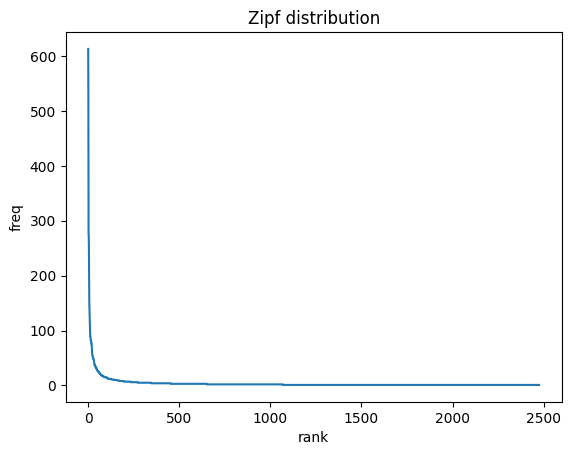

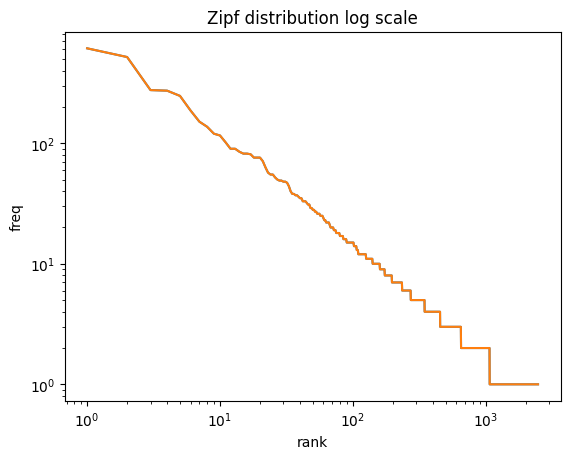


100 bigrammes les plus freq:
['and have' 'and the' 'and then' 'appear to' 'as he' 'as the' 'at least'
 'at the' 'attempt to' 'be in' 'be just' 'be not' 'be one' 'be so'
 'be that' 'be the' 'begin to' 'but it' 'but the' 'by the' 'can not'
 'could have' 'do last' 'do not' 'fail to' 'film be' 'for the' 'for this'
 'from the' 'get the' 'have be' 'have to' 'he be' 'he have' 'here be'
 'high school' 'if the' 'if you' 'in the' 'in this' 'in which' 'it be'
 'know what' 'last summer' 'more than' 'movie be' 'movie have' 'of his'
 'of the' 'of this' 'on the' 'one of' 'rest of' 'seem to' 'she be'
 'so much' 'such as' 'that be' 'that the' 'that you' 'the action'
 'the audience' 'the big' 'the camera' 'the end' 'the film' 'the girl'
 'the good' 'the most' 'the movie' 'the one' 'the only' 'the plot'
 'the rest' 'the script' 'the story' 'there be' 'they be' 'this be'
 'this film' 'this movie' 'this time' 'to be' 'to get' 'to see' 'to the'
 'try to' 'up with' 'want to' 'what be' 'which be' 'who be' 'w

In [29]:
# bow vocab exploring
exploration(alltxts,lambda x:x)

In [ ]:
# vectorization  

def build_vectorizer(name):
    if name == "bow":
        vectorizer = CountVectorizer()
    elif name == "tfidf":
        vectorizer = TfidfVectorizer()
    return vectorizer

def vectorize_txts(alltxts,vec_name):
    vectorizer = build_vectorizer(vec_name)
    X = vectorizer.fit_transform(alltxts)
    return vectorizer,X









In [ ]:
X_train, X_test, y_train, y_test  = train_test_split(X, alllabs, test_size=0.2, random_state=10, shuffle=True)

In [ ]:
kmeans = KMeans(n_clusters=20, random_state=0, max_iter=10).fit(vectors)



def train_model():
    pass

def eval_kmeans(model,train,test):
    """returns accuracy and roc"""
    pass

In [ ]:
def pipeline():
    